Device set to use cuda:0


df_translated loaded successfully. Shape: (5009, 26)
Preprocessing text data...
After preprocessing, dataset shape: (4931, 26)

Starting classification with different thresholds on full dataset...

Classifying with threshold: 0.2


100%|██████████| 155/155 [19:18<00:00,  7.47s/it]



Classifying with threshold: 0.5


100%|██████████| 155/155 [18:04<00:00,  7.00s/it]



Classifying with threshold: 0.7


100%|██████████| 155/155 [17:50<00:00,  6.91s/it]



Performing validation checks on full dataset (using threshold 0.3 for example):


100%|██████████| 155/155 [18:32<00:00,  7.18s/it]



Stance Distribution:
stance
uncertain    3108
exemption     857
support       845
against       121
Name: count, dtype: int64

Confidence Score Statistics:
count    4931.000000
mean        0.333750
std         0.045671
min         0.252608
25%         0.295497
50%         0.330168
75%         0.367564
max         0.470473
Name: confidence_score, dtype: float64

Number of low confidence classifications: 4489

Correlation between text length and confidence: -0.469


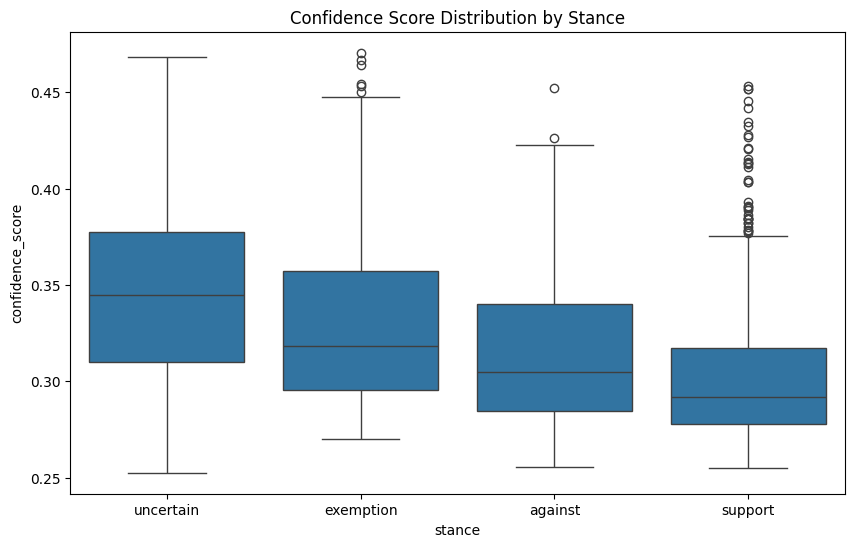


Generating comparative visualizations for different thresholds...


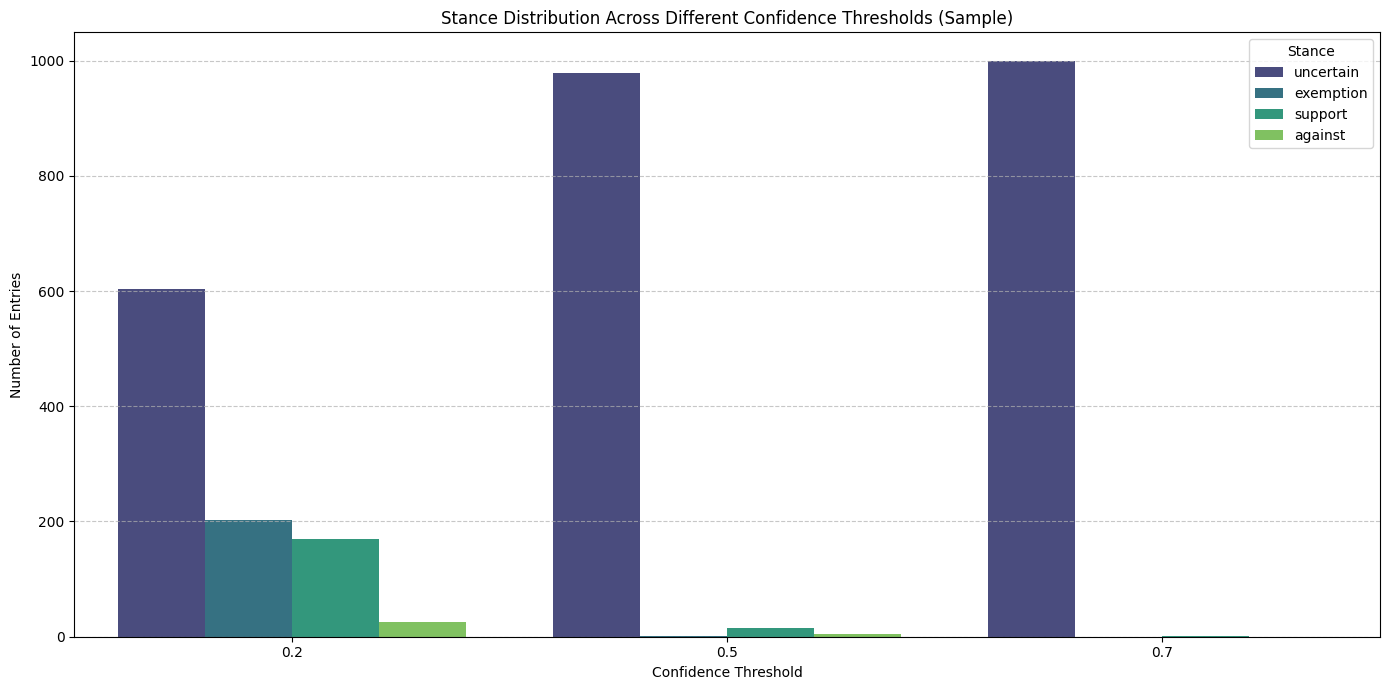

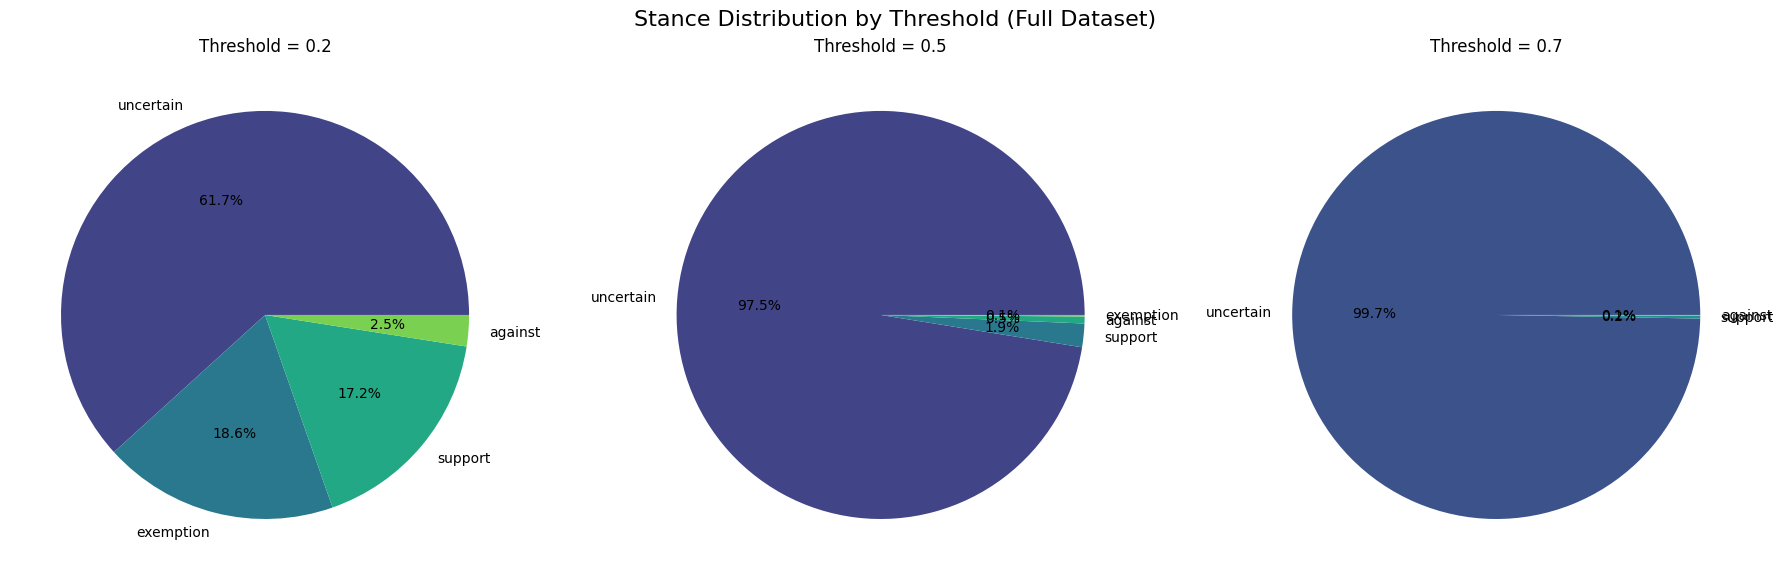

100%|██████████| 32/32 [03:51<00:00,  7.22s/it]


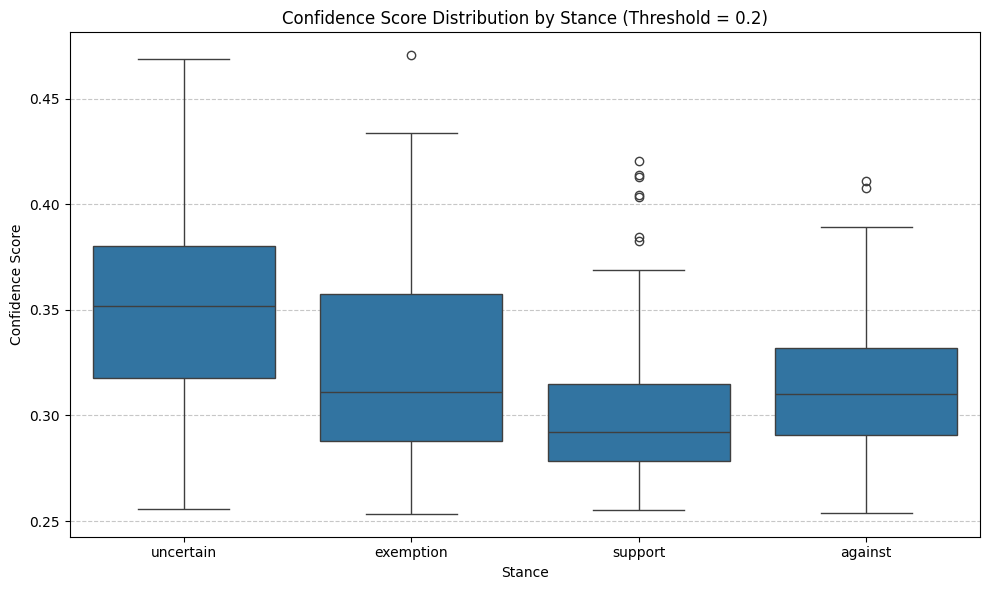

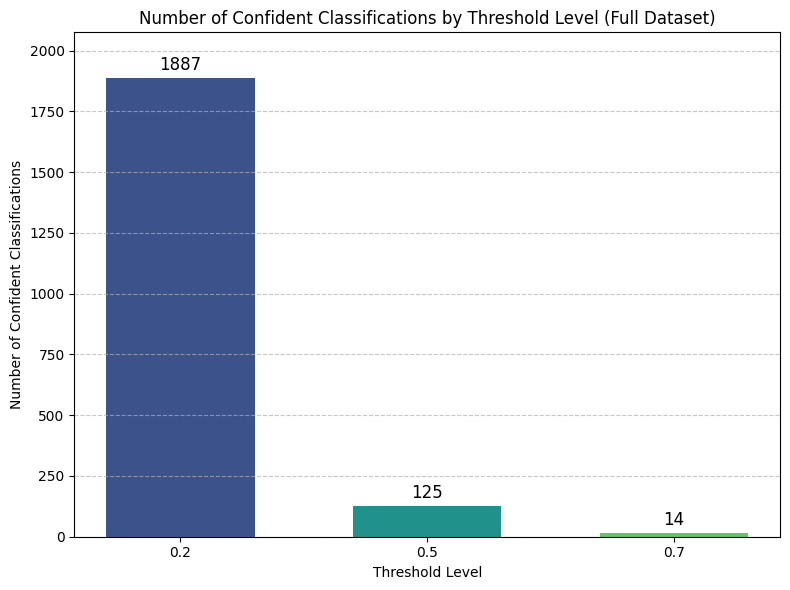


Summary Statistics for Full Dataset:

Threshold 0.2:
stance_T0_2
uncertain    3044
exemption     919
support       846
against       122
Name: count, dtype: int64
Confident classifications: 1887
Percentage confident: 38.3%

Threshold 0.5:
stance_T0_5
uncertain    4806
support        92
against        27
exemption       6
Name: count, dtype: int64
Confident classifications: 125
Percentage confident: 2.5%

Threshold 0.7:
stance_T0_7
uncertain    4917
support        11
against         3
Name: count, dtype: int64
Confident classifications: 14
Percentage confident: 0.3%

Full results with multi-threshold classifications saved to 'df_translated_full_with_multi_threshold_sentiment.csv'
Summary report saved to 'sentiment_analysis_summary_report.csv'

Processing complete! Total records processed: 4931


In [3]:
from transformers import pipeline
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Define candidate labels
candidate_labels = [
    'explicitly endorses the PFAS ban or restriction and provides supporting evidence',
    'strongly argues against the PFAS ban, citing economic impacts or lack of alternatives',
    'requests specific exemptions or transitional periods',
    'provides neutral factual information without clear stance'  # Will be mapped to 'uncertain'
]

# Updated mapping: "neutral" becomes "uncertain"
label_to_stance = {
    'explicitly endorses the PFAS ban or restriction and provides supporting evidence': 'support',
    'strongly argues against the PFAS ban, citing economic impacts or lack of alternatives': 'against',
    'requests specific exemptions or transitional periods': 'exemption',
    'provides neutral factual information without clear stance': 'uncertain'  # Changed from 'neutral'
}

# Load zero-shot classifier
classifier = pipeline("zero-shot-classification",
                     model="facebook/bart-large-mnli",
                     device=0 if torch.cuda.is_available() else -1)

def preprocess_text(text):
    """Clean and preprocess text for classification"""
    if not isinstance(text, str):
        return ""
    text = ' '.join(text.split())  # Remove extra whitespace
    if len(text.split()) < 5:      # Remove very short texts
        return ""
    return text

def classify_with_confidence(text, base_threshold=0.5):
    """Threshold-sensitive classification with stance prioritization"""
    try:
        # Get classification results
        result = classifier(text, candidate_labels)
        labels = result['labels']
        scores = result['scores']
        all_scores = dict(zip(labels, scores))
        
        # Convert to numpy arrays for calculations
        scores_arr = np.array(scores)
        labels_arr = np.array(labels)
        
        # Calculate softmax probabilities
        exp_scores = np.exp(scores_arr)
        probabilities = exp_scores / np.sum(exp_scores)
        
        # Get top prediction
        top_idx = np.argmax(probabilities)
        top_prob = probabilities[top_idx]
        top_label = labels_arr[top_idx]
        stance = label_to_stance[top_label]  # Will map "neutral" to "uncertain"
        
        # Calculate uncertainty metrics
        entropy = -np.sum(probabilities * np.log(probabilities + 1e-10))
        top2_probs = np.partition(probabilities, -2)[-2:]
        margin = top2_probs[-1] - top2_probs[-2]
        
        # Stance-specific thresholds (updated for new uncertainty)
        stance_boost = {
            'support': 0.85,   # Lower threshold for support
            'against': 0.85,   # Lower threshold for against
            'exemption': 0.9,
            'uncertain': 0.95  # Higher threshold for uncertain (formerly neutral)
        }.get(stance, 1.0)
        
        # Dynamic threshold adjustment
        effective_threshold = base_threshold * stance_boost
        
        # Classification rules with stance prioritization
        if top_prob >= effective_threshold:
            # Clear confident classification
            confidence_score = top_prob
            
        elif (top_prob >= effective_threshold * 0.7 and 
              margin >= 0.1 and 
              stance in ['support', 'against']):
            # Accept lower confidence for key stances with good margin
            confidence_score = top_prob
            
        elif (top_prob >= effective_threshold * 0.8 and 
              entropy < 1.0 and 
              margin >= 0.05):
            # Moderate confidence cases
            confidence_score = top_prob
            
        else:
            # Fallback to uncertain for low confidence cases
            stance = 'uncertain'
            confidence_score = top_prob  # Keep actual probability
            
        return {
            'stance': stance,
            'confidence_score': confidence_score,
            'all_scores': all_scores,
            'entropy': entropy
        }

    except Exception as e:
        print(f"Error classifying text: {text[:50]}... | Error: {e}")
        return {
            'stance': 'uncertain',
            'confidence_score': 0.0,
            'all_scores': {},
            'entropy': 0.0
        }

def apply_classification_to_dataframe(df, text_column='combined_text', batch_size=32, threshold=0.3):
    """Apply classification to dataframe with threshold control"""
    results = []
    for i in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[i:i+batch_size]
        batch_results = [classify_with_confidence(text, base_threshold=threshold) 
                        for text in batch[text_column]]
        results.extend(batch_results)
    
    df_classified = df.copy()
    df_classified['stance'] = [r['stance'] for r in results]
    df_classified['confidence_score'] = [r['confidence_score'] for r in results]
    df_classified['all_scores'] = [r['all_scores'] for r in results]
    df_classified['entropy'] = [r['entropy'] for r in results]
    return df_classified
        
def perform_validation_checks(df, text_column='combined_text'):
    """Perform various validation checks on the classification results"""

    # 1. Distribution of stances
    stance_distribution = df['stance'].value_counts()
    print("\nStance Distribution:")
    print(stance_distribution)

    # 2. Confidence score distribution
    print("\nConfidence Score Statistics:")
    print(df['confidence_score'].describe())

    # 3. Check for potential misclassifications
    low_confidence = df[df['confidence_score'] < 0.4]
    print(f"\nNumber of low confidence classifications: {len(low_confidence)}")

    # 4. Analyze text length vs confidence
    df['text_length'] = df[text_column].str.len()
    correlation = df['text_length'].corr(df['confidence_score'])
    print(f"\nCorrelation between text length and confidence: {correlation:.3f}")

    # 5. Plot confidence distribution by stance
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='stance', y='confidence_score', data=df)
    plt.title('Confidence Score Distribution by Stance')
    plt.show()

# --- Main script starts here ---

# Load your df_translated DataFrame
# IMPORTANT: Replace 'df_translated.csv' with the actual path if it's not in the current directory
df_translated = pd.read_csv('df_translated.csv')
print(f"df_translated loaded successfully. Shape: {df_translated.shape}")

# Ensure 'combined_text' column exists
if 'combined_text' not in df_translated.columns:
    raise KeyError("The 'combined_text' column is required but not found in df_translated.")

# Preprocess the combined_text column
print("Preprocessing text data...")
df_translated['combined_text'] = df_translated['combined_text'].apply(preprocess_text)

# Remove rows with empty text after preprocessing
df_translated = df_translated[df_translated['combined_text'] != ''].reset_index(drop=True)
print(f"After preprocessing, dataset shape: {df_translated.shape}")

print("\nStarting classification with different thresholds on full dataset...")

# Define thresholds to test
threshold_levels = [0.2, 0.5, 0.7]

# Create a DataFrame to store results for visualization and saving
comparison_df = df_translated.copy()

all_stance_columns = [] # To keep track of all stance columns for saving

for threshold in threshold_levels:
    print(f"\nClassifying with threshold: {threshold}")
    # Apply classification for the current threshold
    df_temp_classified = apply_classification_to_dataframe(df_translated, threshold=threshold)

    # Add the stance column to the comparison DataFrame with a specific name
    col_name = f'stance_T{str(threshold).replace(".", "_")}'
    comparison_df[col_name] = df_temp_classified['stance']
    all_stance_columns.append(col_name)
    
    # Also add confidence scores for each threshold
    conf_col_name = f'confidence_T{str(threshold).replace(".", "_")}'
    comparison_df[conf_col_name] = df_temp_classified['confidence_score']

# Perform validation checks on one of the classified dataframes (e.g., with threshold 0.3)
print("\nPerforming validation checks on full dataset (using threshold 0.3 for example):")
# Re-run classification for a specific threshold to get the full result set for validation checks
df_full_with_default_threshold = apply_classification_to_dataframe(df_translated, threshold=0.3)
perform_validation_checks(df_full_with_default_threshold)

# --- Comparative Visualization ---
print("\nGenerating comparative visualizations for different thresholds...")

# Take a sample for visualization (to avoid overcrowding)
sample_size_for_viz = min(1000, len(comparison_df))
df_viz_sample = comparison_df.sample(n=sample_size_for_viz, random_state=42)

# Prepare data for plotting
df_melted = df_viz_sample.melt(id_vars=['combined_text'], value_vars=all_stance_columns, var_name='Threshold', value_name='Stance')

# Replace column names with actual threshold values for better labels
df_melted['Threshold'] = df_melted['Threshold'].str.replace('stance_T', '').str.replace('_', '.').astype(float).astype(str)

plt.figure(figsize=(14, 7))
sns.countplot(data=df_melted, x='Threshold', hue='Stance', palette='viridis')
plt.title('Stance Distribution Across Different Confidence Thresholds (Sample)')
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Entries')
plt.legend(title='Stance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create pie charts for each threshold (using full dataset)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Stance Distribution by Threshold (Full Dataset)', fontsize=16)

for idx, threshold in enumerate(threshold_levels):
    col_name = f'stance_T{str(threshold).replace(".", "_")}'
    stance_counts = comparison_df[col_name].value_counts()
    
    # Create pie chart
    axes[idx].pie(stance_counts, labels=stance_counts.index, autopct='%1.1f%%', 
                  colors=sns.color_palette('viridis', len(stance_counts)))
    axes[idx].set_title(f'Threshold = {threshold}')

plt.tight_layout()
plt.show()

# Create confidence interval box plot for the lowest threshold
plt.figure(figsize=(10, 6))
lowest_threshold = min(threshold_levels)
df_lowest_threshold = apply_classification_to_dataframe(df_viz_sample, threshold=lowest_threshold)

sns.boxplot(x='stance', y='confidence_score', data=df_lowest_threshold)
plt.title(f'Confidence Score Distribution by Stance (Threshold = {lowest_threshold})')
plt.xlabel('Stance')
plt.ylabel('Confidence Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate number of confident classifications (excluding 'uncertain') for each threshold
confident_counts = []
for threshold in threshold_levels:
    col_name = f'stance_T{str(threshold).replace(".", "_")}'
    # Count all stances except 'uncertain'
    confident_count = len(comparison_df[comparison_df[col_name] != 'uncertain'])
    confident_counts.append(confident_count)

# Prepare data for bar plot
threshold_labels = [str(t) for t in threshold_levels]

plt.figure(figsize=(8, 6))
bars = plt.bar(threshold_labels, confident_counts, color=sns.color_palette('viridis', len(threshold_levels)), width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(confident_counts)*0.01,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12)

plt.title('Number of Confident Classifications by Threshold Level (Full Dataset)')
plt.xlabel('Threshold Level')
plt.ylabel('Number of Confident Classifications')
plt.ylim(0, max(confident_counts) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display summary statistics
print("\nSummary Statistics for Full Dataset:")
for threshold in threshold_levels:
    col_name = f'stance_T{str(threshold).replace(".", "_")}'
    print(f"\nThreshold {threshold}:")
    print(comparison_df[col_name].value_counts())
    print(f"Confident classifications: {confident_counts[threshold_levels.index(threshold)]}")
    print(f"Percentage confident: {confident_counts[threshold_levels.index(threshold)]/len(comparison_df)*100:.1f}%")

# Save full results with all threshold classifications
output_filename = 'df_translated_full_with_multi_threshold_sentiment.csv'
comparison_df.to_csv(output_filename, index=False, encoding='utf-8')
print(f"\nFull results with multi-threshold classifications saved to '{output_filename}'")

# Also save a summary report
summary_data = []
for threshold in threshold_levels:
    col_name = f'stance_T{str(threshold).replace(".", "_")}'
    stance_counts = comparison_df[col_name].value_counts()
    for stance, count in stance_counts.items():
        summary_data.append({
            'threshold': threshold,
            'stance': stance,
            'count': count,
            'percentage': count/len(comparison_df)*100
        })

summary_df = pd.DataFrame(summary_data)
summary_filename = 'sentiment_analysis_summary_report.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"Summary report saved to '{summary_filename}'")

print(f"\nProcessing complete! Total records processed: {len(comparison_df)}")